In [7]:
import json
import os
METRICS = ['train_hard_loss', 'train_soft_loss', 'train_acc','test_loss', 'test_acc']
def get_metrics(path):
    if not os.path.exists(path):
        # print(f"Error: File not found at path '{path}'.")
        return None
    with open(path, 'r') as f:
        data = json.load(f)
    return tuple(data[metric] for metric in METRICS)

def populate_dict(path):
    if get_metrics(path) == None:
        return None
    return dict(zip(METRICS, get_metrics(path)))

In [13]:
import numpy as np

RUNS = 5 
NOISES = [f'{n:.2f}' for n in np.arange(0, 4, 0.333)]
TARGETS = ['student', 'teacher', 'both']
DATASETS = ['Cifar10', 'Cifar100', 'TinyImageNet']

expf = 'experiments-6'
metrics = {}
for dataset in DATASETS:
    metrics[dataset] = {}
    for noise_target in TARGETS:
        metrics[dataset][noise_target] = {}
        for noise_std in NOISES:
            metrics[dataset][noise_target][noise_std] = {}
            for run in range(RUNS):
                path = f"{expf}/{dataset}/{noise_target}/std{noise_std}/{run}/metrics.json"
                metrics[dataset][noise_target][noise_std][run] = populate_dict(path)


In [14]:
from rich import print as pprint
metrics_average = {}
for dataset in DATASETS:
    metrics_average[dataset] = {}
    for noise_target in TARGETS:
        metrics_average[dataset][noise_target] = {}
        for noise_std in NOISES:
            metrics_average[dataset][noise_target][noise_std] = {}
            counter = 0
            metrics_temp = []
            for run in range(RUNS):
                if metrics[dataset][noise_target][noise_std][run] is not None: 
                    counter += 1
                    metrics_temp.append(metrics[dataset][noise_target][noise_std][run])
            metrics_average[dataset][noise_target][noise_std]['count'] = counter

            if counter == 0: continue
            for met in METRICS:
                stack = []
                for i in range(counter):
                    stack.append(np.array(metrics[dataset][noise_target][noise_std][i][met]))
                stack = np.stack(stack)
                stack_mean = np.mean(stack, axis=0)
                stack_std = np.std(stack, axis=0, ddof=1)

                metrics_average[dataset][noise_target][noise_std][met] = {} 
                metrics_average[dataset][noise_target][noise_std][met]['mean'] = stack_mean
                metrics_average[dataset][noise_target][noise_std][met]['std'] = stack_std


Cifar10


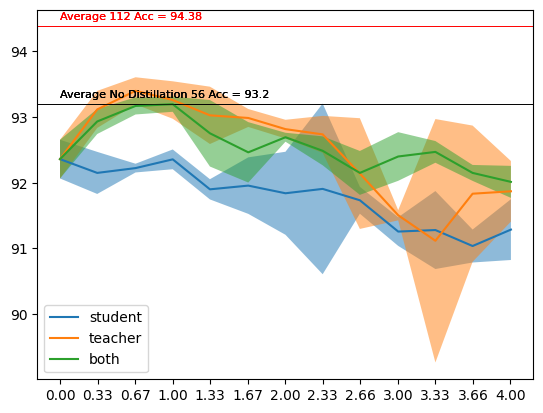

Cifar100


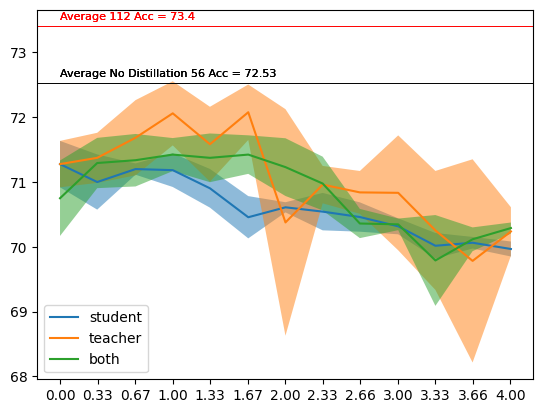

TinyImageNet


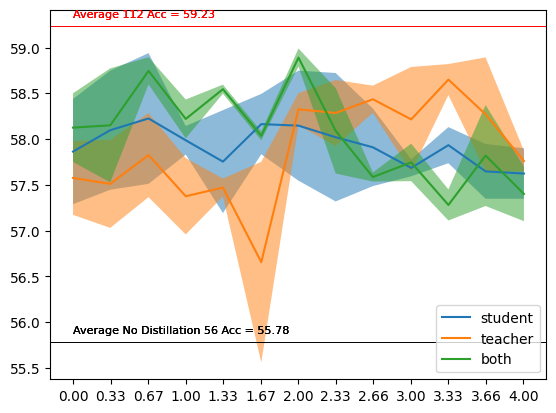

In [15]:
import matplotlib.pyplot as plt
max_accs = {'Cifar10': [93.20,94.38], 'Cifar100': [72.53,73.40], 'TinyImageNet':[55.78,59.23]}
for dataset in DATASETS:
    print(dataset)
    for target in TARGETS:
        counter = 0 
        for noise_std in NOISES:
            if metrics_average[dataset][target][noise_std]['count'] != 0:
                counter += 1


        x   = np.asarray([std for std in NOISES[:counter]], dtype=float)      # cast to float
        y   = np.asarray([metrics_average[dataset][target][std]['test_acc']['mean'][-1] for std in NOISES[:counter]], dtype=float)
        err = np.asarray([metrics_average[dataset][target][std]['test_acc']['std'][-1] for std in NOISES[:counter]], dtype=float)


        plt.plot(x, y, label=target)
        plt.fill_between(x, y-err, y+err, alpha=0.5)   # element-wise OK now
        plt.xticks(np.arange(0, 4, 0.333), NOISES)

        plt.axhline(y=max_accs[dataset][0], color='black', linestyle='-', linewidth=0.5)
        plt.text(0, max_accs[dataset][0] + 0.1, f"Average No Distillation 56 Acc = {max_accs[dataset][0]}", color='black', fontsize=8)

        plt.axhline(y=max_accs[dataset][1], color='red', linestyle='-', linewidth=0.5)
        plt.text(0, max_accs[dataset][1] + 0.1, f"Average 112 Acc = {max_accs[dataset][1]}", color='red', fontsize=8)

    plt.legend()
    plt.show()

# DATA VIZ

In [12]:
TIMES = {'Cifar10': '1:45:00', 'Cifar100': '2:30:00', 'TinyImageNet':'11:00:00'}

def converter(time):
    time = TIMES[time]
    hours = int(time.split(':')[0])
    minutes = int(time.split(':')[1])/60
    return hours + minutes

mult = {}
for time in TIMES:
    mult[time] = converter(time)

TOTAL = RUNS * len(TARGETS) * len(DATASETS) * len(NOISES)
print("TOTAL", TOTAL)

total_hours = 0
hours_left = 0
for dataset in DATASETS:
    for noise_target in TARGETS:
        for noise_std in NOISES:
            for run in range(RUNS):
                total_hours += mult[dataset]
                if metrics[dataset][noise_target][noise_std][run] is None: 
                    hours_left += mult[dataset]
print('total hours', total_hours)
print('total hours left', hours_left)

TOTAL 585
total hours 2973.75
total hours left 1508.5


In [ ]:
# HOW MANY DID I TRAIN THUS FAR?
for dataset in DATASETS:
    for noise_target in TARGETS:
        print(dataset, noise_target)
        noises = []
        for noise_std in NOISES:
            count = metrics_average[dataset][noise_target][noise_std]['count']
            noises.append(count)
        print(noises)
    print()

In [ ]:
def visualize_structure(things, max_depth=6):
    def recurse(level, indent=0):
        if indent >= max_depth:
            return  # stop at max depth
        if isinstance(level, dict):
            for key in level:
                print('  ' * indent + f"- {key}")
                recurse(level[key], indent + 1)

    print("Structure of 'things':")
    recurse(things)

visualize_structure(metrics_average)

for dataset in DATASETS:
    for noise_target in TARGETS:
        for noise_std in NOISES:
            print(dataset, noise_target, noise_std)
            print(metrics_average[dataset][noise_target][noise_std]['count'])

# NUMBER 5

Cifar10


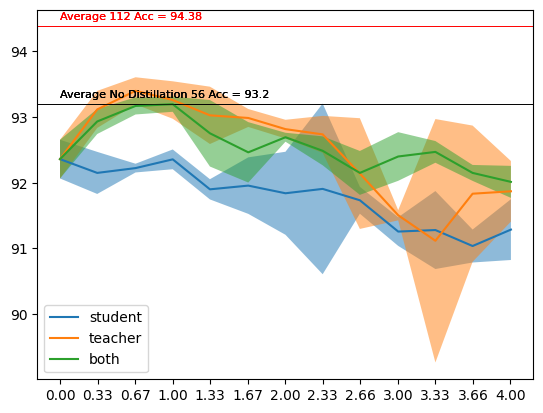

Cifar100


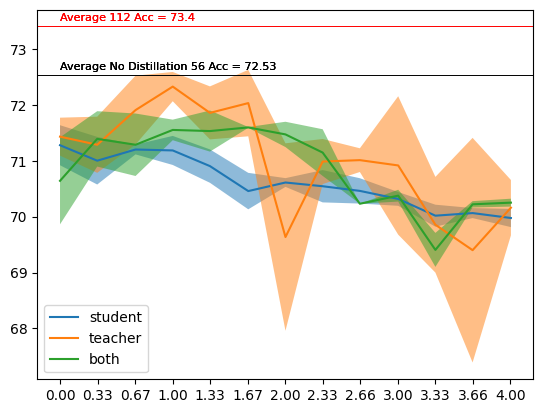

TinyImageNet


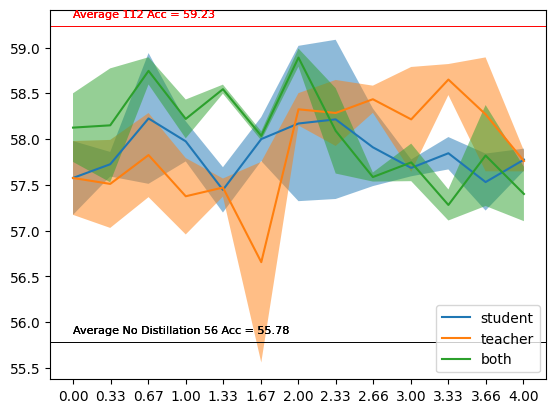

In [5]:
import matplotlib.pyplot as plt
max_accs = {'Cifar10': [93.20,94.38], 'Cifar100': [72.53,73.40], 'TinyImageNet':[55.78,59.23]}
for dataset in DATASETS:
    print(dataset)
    for target in TARGETS:
        counter = 0 
        for noise_std in NOISES:
            if metrics_average[dataset][target][noise_std]['count'] != 0:
                counter += 1


        x   = np.asarray([std for std in NOISES[:counter]], dtype=float)      # cast to float
        y   = np.asarray([metrics_average[dataset][target][std]['test_acc']['mean'][-1] for std in NOISES[:counter]], dtype=float)
        err = np.asarray([metrics_average[dataset][target][std]['test_acc']['std'][-1] for std in NOISES[:counter]], dtype=float)


        plt.plot(x, y, label=target)
        plt.fill_between(x, y-err, y+err, alpha=0.5)   # element-wise OK now
        plt.xticks(np.arange(0, 4, 0.333), NOISES)

        plt.axhline(y=max_accs[dataset][0], color='black', linestyle='-', linewidth=0.5)
        plt.text(0, max_accs[dataset][0] + 0.1, f"Average No Distillation 56 Acc = {max_accs[dataset][0]}", color='black', fontsize=8)

        plt.axhline(y=max_accs[dataset][1], color='red', linestyle='-', linewidth=0.5)
        plt.text(0, max_accs[dataset][1] + 0.1, f"Average 112 Acc = {max_accs[dataset][1]}", color='red', fontsize=8)

    plt.legend()
    plt.show()

In [6]:
# HOW MANY DID I TRAIN THUS FAR?
for dataset in DATASETS:
    for noise_target in TARGETS:
        print(dataset, noise_target)
        noises = []
        for noise_std in NOISES:
            count = metrics_average[dataset][noise_target][noise_std]['count']
            noises.append(count)
        print(noises)
    print()

Cifar10 student
[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
Cifar10 teacher
[3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3]
Cifar10 both
[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]

Cifar100 student
[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2]
Cifar100 teacher
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
Cifar100 both
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]

TinyImageNet student
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
TinyImageNet teacher
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
TinyImageNet both
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]

